In [2]:
import pandas as pd
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import numpy as np
import time
import asyncio
import httpx
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import time
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.max_columns = None
from scipy import stats
import numpy as np


In [21]:
df = pd.read_csv('comprehensive_non_apartment_sales.csv')

df_lej = pd.read_csv('comprehensive_apartment_sales.csv')

df_lej['btype'] = 'Ejerlejlighed'

df = pd.concat([df, df_lej], ignore_index=True)
print(df.head())
print(df.shape)

if 'dato_x' in df.columns:
    df['dato'] = df['dato_x']
    df.drop(columns=['dato_x'], inplace=True)


if all(col in df.columns for col in ['samlet_koebesum', 'kontant_koebesum', 'købesum']):
    
    for col in ['købesum', 'samlet_koebesum', 'kontant_koebesum']:
        low_count = (df[col] < 10000).sum()
        nan_count = df[col].isna().sum()
    
    problematic_kobesum = (df['købesum'] < 100000) | df['købesum'].isna()
    good_samlet = (df['samlet_koebesum'] >= 100000) & df['samlet_koebesum'].notna()
    
    samlet_fixes = problematic_kobesum & good_samlet
    df.loc[samlet_fixes, 'købesum'] = df.loc[samlet_fixes, 'samlet_koebesum']


    still_problematic = (df['købesum'] < 100000) | df['købesum'].isna()
    good_kontant = (df['kontant_koebesum'] >= 100000) & df['kontant_koebesum'].notna()

    kontant_fixes = still_problematic & good_kontant
    df.loc[kontant_fixes, 'købesum'] = df.loc[kontant_fixes, 'kontant_koebesum']
    
    
    
df.drop(columns=['samlet_koebesum', 'kontant_koebesum', 'loesoeresum', 'salgstype', 'status'], inplace=True)
print (len(df))



   bfe_nummer  købesum  samlet_koebesum  kontant_koebesum  loesoeresum  \
0     1300001  1345335          1345335               NaN          NaN   
1     1300001  1345335          1345335               NaN          NaN   
2     1300001  1525000          1525000               NaN          NaN   
3     1300001  1525000          1525000               NaN          NaN   
4     1300001  1525000          1525000               NaN          NaN   

                      dato_x  sale_sequence  total_sales  is_most_recent  \
0  2003-10-31 23:00:00+00:00              1            6           False   
1  2003-10-31 23:00:00+00:00              2            6           False   
2  2004-06-30 22:00:00+00:00              3            6           False   
3  2004-06-30 22:10:00+00:00              4            6           False   
4  2004-06-30 22:20:00+00:00              5            6           False   

   prev_købesum  price_change  price_change_pct             prev_sale_date  \
0           NaN     

In [22]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")



Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 161


In [23]:

lowest_prices = df.nsmallest(10, 'købesum')
print(lowest_prices[[ 'købesum', 'm2', 'bfe_nummer']])

        købesum     m2  bfe_nummer
11324         1  206.0     1341764
28593         1  166.0     1800261
146784        1  150.0     2120969
245801        1  162.0     2209280
361876        1   97.0     2309788
361881        1  104.0     2309789
361887        1   77.0     2309790
361893        1   81.0     2309791
361897        1  119.0     2309792
361902        1   73.0     2309793


In [24]:
    
df = df.drop_duplicates(subset=['bfe_nummer', 'dato'], keep='first')
print (len(df))

2805351


In [25]:

df['dato'] = pd.to_datetime(df['dato'])

old_dates_mask = df['dato'] < '1992-01-01'
old_dates_data = df[old_dates_mask]

df = df[df['dato'] >= '1992-01-01']
print (len(df))


2554923


In [26]:

df['pris_pr_m2'] = df['købesum'] / df['m2']

suspicious_total = df['købesum'] < 25000 
suspicious_m2 = df['pris_pr_m2'] <  1000 

total_suspicious = suspicious_total | suspicious_m2
df = df[~total_suspicious].copy()

lower_percentile = np.percentile(df['købesum'], 0.1)
upper_percentile = np.percentile(df['købesum'], 99.9)

df = df[(df['købesum'] >= lower_percentile) & (df['købesum'] <= upper_percentile)]


len(df)

2509363

In [28]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 161


In [29]:
#df['dato'] = pd.to_datetime(df['dato']) # im making date the index
df = df.sort_values('dato')
df = df.set_index('dato')

In [17]:
print(df.shape)

(2352739, 26)


In [30]:
#here i get the rolling mean for price per square meter for different time windows and geographical areas

df = df.sort_index()

levels = ['postnummer', ['postnummer', 'btype']]  # All properties in postnummer, then by postnummer + btype
time_windows = ['365D']

for level in levels:
    for window in time_windows:
        if isinstance(level, list):
            level_name = '_'.join(level)
            new_col_name = f'pris_pr_m2_mean_{window}_{level_name}'
        else:
            level_name = level
            new_col_name = f'pris_pr_m2_mean_{window}_{level_name}'
        
        #calculates rolling mean for price per square meter
        df[new_col_name] = df.groupby(level)['pris_pr_m2'].transform(
            lambda x: x.rolling(window, min_periods=1, closed='left').mean()
        ) #the first values will be nan, so we fill them with 0 we discard later
        print(f"Calculated {new_col_name}")

Calculated pris_pr_m2_mean_365D_postnummer
Calculated pris_pr_m2_mean_365D_postnummer_btype


In [19]:
df.tail(1000010)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011-10-27 22:00:00+00:00,4457433,1175000,2,2,True,630000.0,545000.0,86.507937,1996-02-29 23:00:00+00:00,15.655031,1175000,4,1970,29-09-2011,Alm. Salg,107.0,Villa,"Toustrupvej 12, Snejbjerg",7400,Herning,Sydjylland,Jylland,"Toustrupvej 12, Snejbjerg, 7400 Herning",8.899305,56.130485,10981.308411,10808.089228,9985.418668
2011-10-27 22:00:00+00:00,5708457,1750000,6,6,True,822500.0,927500.0,112.765957,2005-12-14 23:00:00+00:00,5.864476,1750000,6,2004,25-06-2011,Alm. Salg,176.0,Villa,"Tjørring Hovedgade 61, Tjørring",7400,Herning,Sydjylland,Jylland,"Tjørring Hovedgade 61, Tjørring, 7400 Herning",8.921474,56.164148,9943.181818,10808.089228,9985.418668
2011-10-27 22:00:00+00:00,2693253,1225000,3,3,True,800000.0,425000.0,53.125000,2004-06-14 22:00:00+00:00,7.367556,1225000,5,1979,16-10-2011,Alm. Salg,80.0,Fritidshus,"Nordbakken 12, Sandager Næs",5610,Assens,Fyn og øer,Fyn og øer,"Nordbakken 12, Sandager Næs, 5610 Assens",9.880713,55.332732,15312.500000,8644.236366,11069.402473
2011-10-27 22:00:00+00:00,5426063,650000,2,2,True,415000.0,235000.0,56.626506,1991-10-31 23:00:00+00:00,19.986311,650000,4,1964,16-10-2011,Alm. Salg,136.0,Villa,Fromsgade 37B,4800,Nykøbing F,Andre øer,Sjælland,"Fromsgade 37B, 4800 Nykøbing F",11.878146,54.759382,4779.411765,9220.620340,8733.458714
2011-10-27 22:00:00+00:00,3265540,1600000,5,5,True,800000.0,800000.0,100.000000,2007-03-31 22:00:00+00:00,4.574949,1600000,4,1986,17-07-2011,Alm. Salg,241.0,Villa,Lilleholm 56,9370,Hals,Nordjylland,Jylland,"Lilleholm 56, 9370 Hals",10.317924,56.998614,6639.004149,9149.657417,7559.648163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26 22:00:00+00:00,9749175,3755000,3,3,True,2925000.0,830000.0,28.376068,2013-12-18 23:00:00+00:00,11.518138,2925000,7,2007,06-12-2013,Alm. Salg,207.0,Villa,Eventyrbakken 23,9240,Nibe,Nordjylland,Jylland,"Eventyrbakken 23, 9240 Nibe",9.644244,56.972740,18140.096618,12238.127665,12138.652679
2025-06-26 22:00:00+00:00,2690966,1325000,2,2,True,1325000.0,0.0,0.000000,2020-08-30 22:00:00+00:00,4.821355,1325000,6,1976,20-07-2020,Alm. Salg,171.0,Villa,Havrevænget 12,5620,Glamsbjerg,Fyn og øer,Fyn og øer,"Havrevænget 12, 5620 Glamsbjerg",10.112515,55.278373,7748.538012,8041.218646,7640.645498
2025-06-26 22:00:00+00:00,2469611,1250000,4,4,True,792500.0,457500.0,57.728707,2006-01-31 23:00:00+00:00,19.397673,707000,7,1973,30-07-2017,Auktion,166.0,Villa,"Enggårdsvej 40, Ubby",4490,Jerslev Sjælland,Andre øer,Sjælland,"Enggårdsvej 40, Ubby, 4490 Jerslev Sjælland",11.217667,55.615554,7530.120482,9417.776369,9428.547582


In [ ]:
# Filter for postnummer 2960 and date range
df_filtered = df[
    (df['postnummer'] == 2960) & 
    (pd.to_datetime(df['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

In [20]:
df.to_csv("afterlagtesttest.csv")

In [ ]:
df = pd.read_csv("afterlagtesttest.csv")

In [22]:
df.head(10)


,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1992-01-01 23:00:00+00:00,206973,296270,1,4,False,NaN,NaN,NaN,NaN,NaN,2150000,3,1962,30-03-2008,Alm. Salg,101.0,Ejerlejlighed,"Lehwaldsvej 3, 5. d",2800,Kongens Lyngby,"Hovedstaden, København",Sjælland,"Lehwaldsvej 3, 5. d, 2800 Kongens Lyngby",12.500846,55.768293,2933.366337,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,3138910,250000,1,1,True,NaN,NaN,NaN,NaN,NaN,1500000,5,1925,06-03-2019,Fam. Salg,65.0,Fritidshus,Lærkevænget 14,4873,Væggerløse,Andre øer,Sjælland,"Lærkevænget 14, 4873 Væggerløse",11.974325,54.698888,3846.153846,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,5155506,150000,1,3,False,NaN,NaN,NaN,NaN,NaN,1695000,4,1973,04-07-2024,Alm. Salg,64.0,Fritidshus,"Poserevænget 2, Pedersker",3720,Aakirkeby,Bornholm,Bornholm,"Poserevænget 2, Pedersker, 3720 Aakirkeby",14.978819,55.004558,2343.750000,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,3417987,215000,1,3,False,NaN,NaN,NaN,NaN,NaN,150000,4,1900,12-04-2023,Alm. Salg,79.0,Villa,"Hedegårdsvej 20, Svankjær",7755,Bedsted Thy,Sydjylland,Jylland,"Hedegårdsvej 20, Svankjær, 7755 Bedsted Thy",8.363135,56.845062,2721.518987,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,2103889,1355000,1,2,False,NaN,NaN,NaN,NaN,NaN,2890000,5,1971,18-12-2023,Fam. Salg,152.0,Rækkehus,"Gassehaven 101, Gl Holte",2840,Holte,"Hovedstaden, København",Sjælland,"Gassehaven 101, Gl Holte, 2840 Holte",12.513967,55.831114,8914.473684,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,4431237,1100000,1,2,False,NaN,NaN,NaN,NaN,NaN,1875000,4,1967,25-11-2018,Alm. Salg,108.0,Villa,"Sdr. Greenvej 13, Arnborg",7400,Herning,Sydjylland,Jylland,"Sdr. Greenvej 13, Arnborg, 7400 Herning",8.977579,55.993369,10185.185185,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,406166,2115000,1,2,False,NaN,NaN,NaN,NaN,NaN,1750000,4,1941,12-07-2020,Alm. Salg,122.0,Ejerlejlighed,"Nørregade 4B, 2.",9850,Hirtshals,Nordjylland,Jylland,"Nørregade 4B, 2., 9850 Hirtshals",9.956707,57.590271,17336.065574,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,2675225,710000,1,4,False,NaN,NaN,NaN,NaN,NaN,875000,4,1913,13-03-2023,Alm. Salg,155.0,Villa,"Bogensevej 18, Gamby",5471,Søndersø,Fyn og øer,Fyn og øer,"Bogensevej 18, Gamby, 5471 Søndersø",10.085108,55.473097,4580.645161,NaN,NaN,NaN
1992-01-01 23:00:00+00:00,2220218,855000,1,3,False,NaN,NaN,NaN,NaN,NaN,2525000,7,1880,01-07-2005,Alm. Salg,150.0,Villa,Ørsted Bygade 11,4622,Havdrup,Andre øer,Sjælland,"Ørsted Bygade 11, 4622 Havdrup",12.078528,55.543542,5700.000000,NaN,NaN,NaN


In [ ]:
df = df.reset_index()

df['pris_pr_m2_prev'] = df['prev_købesum'] / df['m2']  

df['dato'] = pd.to_datetime(df['dato'], errors='coerce', utc=True)

df.sort_values(['bfe_nummer', 'dato'], inplace=True)

df['prev_sale_date'] = df.groupby('bfe_nummer')['dato'].shift(1)
df['prev_købesum'] = df.groupby('bfe_nummer')['købesum'].shift(1)
df['pris_pr_m2_prev'] = df.groupby('bfe_nummer')['pris_pr_m2'].shift(1)
df['pris_pr_m2_mean_postummer_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer'].shift(1)
df['pris_pr_m2_mean_postnummer_btype_prev'] = df.groupby('bfe_nummer')['pris_pr_m2_mean_365D_postnummer_btype'].shift(1)

#df['price_change'] = df['købesum'] - df['prev_købesum']
#df['price_change_pct'] = (df['price_change'] / df['prev_købesum']) * 100

df.set_index('dato', inplace=True)

df['days_since_last_sale'] = (df.index - df['prev_sale_date']).dt.days


In [59]:
df.head(10)

,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2_temp,pris_pr_m2,pris_pr_m2_prev,pris_pr_m2_mean_30D_by,pris_pr_m2_mean_180D_by,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_30D_postnummer,pris_pr_m2_mean_180D_postnummer,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_30D_område,pris_pr_m2_mean_180D_område,pris_pr_m2_mean_365D_område,pris_pr_m2_mean_30D_region,pris_pr_m2_mean_180D_region,pris_pr_m2_mean_365D_region,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-12-02 23:00:00+00:00,100000,4296181,1,1,True,NaN,NaN,NaN,NaT,NaN,4296181,3,2019,11-12-2017,Alm. Salg,133.0,Ejerlejlighed,"Stadionvej 86, 3. 1",2600,Glostrup,"Hovedstaden, København",Sjælland,"Stadionvej 86, 3. 1, 2600 Glostrup",12.374093,55.667897,32302.112782,32302.112782,NaN,28562.422858,26461.939729,25434.196252,28562.422858,26461.939729,25434.196252,36088.301542,34966.830985,34493.509286,32972.455435,31952.834894,31551.749696,NaN,NaN,NaN
2018-10-14 22:00:00+00:00,100030,2048000,1,3,False,NaN,NaN,NaN,NaT,NaN,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,21557.894737,21557.894737,NaN,17779.805432,17045.945373,17766.585423,17779.805432,17045.945373,17766.585423,14957.363891,14474.750297,14736.436189,21486.789671,21880.027114,22055.663780,NaN,NaN,NaN
2019-09-12 22:00:00+00:00,100030,2025000,2,3,False,2048000.0,-23000.0,-1.123047,2018-10-14 22:00:00+00:00,0.911704,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,21315.789474,21315.789474,21557.894737,17866.325322,17615.640232,17460.604202,17866.325322,17615.640232,17460.604202,16078.608639,16408.236912,15874.301095,23522.688118,23859.629895,22778.456746,17766.585423,17766.585423,333.0
2020-09-29 22:00:00+00:00,100030,2198000,3,3,True,2025000.0,173000.0,8.543210,2019-09-12 22:00:00+00:00,1.048597,2198000,3,1929,28-07-2020,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, st.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, st., 6700 Esbjerg",8.446658,55.470418,23136.842105,23136.842105,21315.789474,18702.905040,17093.932735,17123.704883,18702.905040,17093.932735,17123.704883,16953.712985,16070.472866,15390.167131,23648.046235,22985.000398,22480.700392,17460.604202,17460.604202,383.0
2018-09-30 22:00:00+00:00,100031,2798000,1,2,False,NaN,NaN,NaN,NaT,NaN,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,21037.593985,21037.593985,NaN,17272.023346,17032.428974,17534.125740,17272.023346,17032.428974,17534.125740,14665.031372,14550.461378,14800.196460,22667.005074,21985.619463,22212.970611,NaN,NaN,NaN
2019-03-20 23:00:00+00:00,100031,2998000,2,2,True,2798000.0,200000.0,7.147963,2018-09-30 22:00:00+00:00,0.468172,2998000,4,1929,28-02-2019,Alm. Salg,133.0,Ejerlejlighed,"Kronprinsensgade 59, 1. th",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 59, 1. th, 6700 Esbjerg",8.446777,55.470578,22541.353383,22541.353383,21037.593985,17610.104413,17425.131419,17231.986035,17610.104413,17425.131419,17231.986035,14695.700856,15331.632227,15006.996356,19634.945505,21562.769030,21731.016994,17534.125740,17534.125740,171.0
2018-09-20 22:00:00+00:00,100032,2098000,1,1,True,NaN,NaN,NaN,NaT,NaN,2098000,3,1929,20-09-2018,Alm. Salg,95.0,Ejerlejlighed,"Kronprinsensgade 55, 1.",6700,Esbjerg,Sydjylland,Jylland,"Kronprinsensgade 55, 1., 6700 Esbjerg",8.446658,55.470418,22084.210526,22084.210526,NaN,16884.291200,17135.272653,17484.471326,16884.291200,17135.272653,17484.471326,13819.185490,1453

In [26]:
def nnfeatures(df: pd.DataFrame, k_values: list, closeness_feature_cols: list, value_col: str, date_col='dato', lookback_days=365):
    #For each property, find nearby properties that sold recently and calculate their mean
    scaler = StandardScaler()
    # i think it is important, unless you live in the middle of the earth
    X_scaled = scaler.fit_transform(df[closeness_feature_cols])
    
    # we need to get more than max k, becouse we will cut many away. 4 is magic number, after further analasys i dont think it matters 
    max_k = max(k_values)
    radius = max_k * 8# increased from earlier version, honstly can be played around with
    nn_model = NearestNeighbors(n_neighbors=radius, metric='euclidean')
    nn_model.fit(X_scaled)
    # Get distances and indices of neighbors for every point
    distances, indices = nn_model.kneighbors(X_scaled)

    all_results = []
    
    all_dates = df.index.values
    all_values = df[value_col].values
    all_btypes = df['btype'].values  
    total_rows = len(df)

    loop_start_time = time.time()

    for i in range(total_rows):
        #for every 50000 rows, print the progress and rate
        if (i + 1) % 50000 == 0:
            elapsed = time.time() - loop_start_time
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            print(f"--- Processed {i + 1} / {total_rows} properties ({rate:.0f} rows/sec) ---")
        #get the rows sales date    
        target_date = all_dates[i]
        target_btype = all_btypes[i]  

        #get the indices of the neighbors
        neighbor_indices = indices[i]
        #get the dates of the neighbors
        neighbor_dates = all_dates[neighbor_indices]
        neighbor_btypes = all_btypes[neighbor_indices]  # Get neighbor building types

        
        #filter the neighbors by the time window, it needs to have happened before to prevent data leakage, but not to much before to avoid old data
        time_window_mask = (neighbor_dates < target_date) & \
(neighbor_dates >= (target_date - pd.Timedelta(days=lookback_days)))
        # the neighbors that get through the time mask 

        valid_neighbor_indices = neighbor_indices[time_window_mask]
        valid_neighbor_btypes = neighbor_btypes[time_window_mask]

         # Filter for same building type
        btype_mask = valid_neighbor_btypes == target_btype
        valid_samebtype_indices = valid_neighbor_indices[btype_mask]
        
        row_stats = {}
        for k in k_values:
            # Get the top k valid neighbors
            final_indices = valid_neighbor_indices[:k]
            
            num_neighbors = len(final_indices)
            #get the stats
            if num_neighbors > 0:
                neighbor_values = all_values[final_indices]
                row_stats[f'num_of_{k}_neighbors'] = num_neighbors
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.mean(neighbor_values)
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.std(neighbor_values)
            else:
                row_stats[f'mean_of_{k}_neighbors_{value_col}'] = np.nan
                row_stats[f'std_of_{k}_neighbors_{value_col}'] = np.nan

            final_samebtype_indices = valid_samebtype_indices[:k]
            num_samebtype_neighbors = len(final_samebtype_indices)
            
            if num_samebtype_neighbors > 0:
                samebtype_neighbor_values = all_values[final_samebtype_indices]
                row_stats[f'num_of_{k}_samebtype_neighbors'] = num_samebtype_neighbors
                row_stats[f'mean_of_{k}_samebtype_neighbors_{value_col}'] = np.mean(samebtype_neighbor_values)
                row_stats[f'std_of_{k}_samebtype_neighbors_{value_col}'] = np.std(samebtype_neighbor_values)
            else:
                row_stats[f'mean_of_{k}_samebtype_neighbors_{value_col}'] = np.nan
                row_stats[f'std_of_{k}_samebtype_neighbors_{value_col}'] = np.nan    
        
        all_results.append(row_stats)
    
    end_time = time.time()
    print(f"finished in {(end_time - loop_start_time)/60:.2f} minutes")

    return pd.DataFrame(all_results, index=df.index)


k = [5, 15, 30]
coordinates = ['x', 'y'] 
target_col = 'pris_pr_m2'

neighbor_features_df = nnfeatures(
    df=df,
    k_values=k,
    closeness_feature_cols=coordinates,
    value_col=target_col
)
df_final = pd.concat([df, neighbor_features_df], axis=1)



# Compare the property previous price to the market average at that time
df_final['historical_premium_vs_postnummer'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postummer_prev']
df_final['historical_premium_vs_postnummer_pct'] = (df_final['historical_premium_vs_postnummer'] / df_final['pris_pr_m2_mean_postummer_prev']) * 100

df_final['historical_premium_vs_postnummer_btype'] = df_final['pris_pr_m2_prev'] - df_final['pris_pr_m2_mean_postnummer_btype_prev']
df_final['historical_premium_vs_postnummer_btype_pct'] = (df_final['historical_premium_vs_postnummer_btype'] / df_final['pris_pr_m2_mean_postnummer_btype_prev']) * 100 # we are getting some crazy column names


--- Processed 50000 / 2352739 properties (11676 rows/sec) ---
--- Processed 100000 / 2352739 properties (11696 rows/sec) ---
--- Processed 150000 / 2352739 properties (11614 rows/sec) ---
--- Processed 200000 / 2352739 properties (11668 rows/sec) ---
--- Processed 250000 / 2352739 properties (11689 rows/sec) ---
--- Processed 300000 / 2352739 properties (11728 rows/sec) ---
--- Processed 350000 / 2352739 properties (11732 rows/sec) ---
--- Processed 400000 / 2352739 properties (11632 rows/sec) ---
--- Processed 450000 / 2352739 properties (11701 rows/sec) ---
--- Processed 500000 / 2352739 properties (11723 rows/sec) ---
--- Processed 550000 / 2352739 properties (11739 rows/sec) ---
--- Processed 600000 / 2352739 properties (11750 rows/sec) ---
--- Processed 650000 / 2352739 properties (11721 rows/sec) ---
--- Processed 700000 / 2352739 properties (11725 rows/sec) ---
--- Processed 750000 / 2352739 properties (11733 rows/sec) ---
--- Processed 800000 / 2352739 properties (11738 rows/se

In [97]:
df_final.to_csv("with_neighborstesttest.csv")

In [28]:
df=df_final.copy()

In [110]:
df= pd.read_csv("with_neighborstesttest.csv")
print(df.shape)

(2352739, 57)


In [115]:
(df['btype'] == 'Ejerlejlighed').sum()

np.int64(423450)

In [46]:
df.sample(15) # cool huh. these are the two cool features that i made, mean of the neighbors and mean of the area. they are very similar

,level_0,index,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,std_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,std_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,std_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,std_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1992-09-30 23:00:00+00:00,1346649,15749,4232230,685000,1,1,True,NaN,NaN,NaN,NaT,NaN,2515000,5,1936,21-12-2023,Fam. Salg,224.0,Villa,"Bøgeskovvej 12, Rasborg",8355,Solbjerg,Øst- og Midtjylland,Jylland,"Bøgeskovvej 12, Rasborg, 8355 Solbjerg",10.084424,56.022125,3058.035714,6215.542895,4485.977889,NaN,NaN,NaN,NaN,2.0,4622.390351,289.890351,1.0,4332.500000,0.000000,2.0,4622.390351,289.890351,1.0,4332.500000,0.000000,2.0,4622.390351,289.890351,1.0,4332.500000,0.000000,NaN,NaN,NaN,NaN
2007-12-31 23:00:00+00:00,505852,1124748,2116166,2325000,2,2,True,2325000.0,0.0,0.000000,2007-12-18 23:00:00+00:00,0.035592,4650000,7,1971,20-10-2007,Alm. Salg,225.0,Villa,Skovbuen 49,2605,Brøndby,"Hovedstaden, København",Sjælland,"Skovbuen 49, 2605 Brøndby",12.429315,55.652162,10333.333333,16727.159207,15299.506181,10333.333333,16752.797691,15299.044696,13.0,5.0,17875.283821,7826.564569,5.0,17875.283821,7826.564569,9.0,18507.782950,7660.219582,8.0,18086.880819,8026.170140,9.0,18507.782950,7660.219582,8.0,18086.880819,8026.170140,-6419.464357,-38.318760,-4965.711363,-32.457656
2001-12-09 23:00:00+00:00,1517713,534670,4509417,415000,1,1,True,NaN,NaN,NaN,NaT,NaN,415000,3,1927,28-08-2001,Alm. Salg,126.0,Villa,Åbakkevej 8,7540,Haderup,Sydjylland,Jylland,"Åbakkevej 8, 7540 Haderup",8.995979,56.388067,3293.650794,3542.454837,3243.679652,NaN,NaN,NaN,NaN,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,2.0,2404.815230,135.078387,NaN,NaN,NaN,NaN
2020-02-27 23:00:00+00:00,1896774,1938566,5682967,1275000,4,4,True,918002.0,356998.0,38.888586,2004-12-30 23:00:00+00:00,15.159480,1275000,3,1981,18-02-2020,Alm. Salg,99.0,Rækkehus,Bjolderupvej 23A,6000,Kolding,Sydjylland,Jylland,"Bjolderupvej 23A, 6000 Kolding",9.475835,55.473409,12878.787879,13461.043551,15898.452453,9272.747475,7322.059149,8878.281240,5537.0,5.0,11546.158146,3770.160585,1.0,14141.414141,0.000000,6.0,12627.262936,4205.832878,1.0,14141.414141,0.000000,6.0,12627.262936,4205.832878,1.0,14141.414141,0.000000,1950.688326,26.641253,394.466234,4.443047
2003-10-31 23:10:00+00:00,1055475,706193,3171048,492500,3,4,False,492500.0,0.0,0.000000,2003-10-31 23:00:00+00:00,0.000000,1595000,5,2001,13-11-2023,Alm. Salg,79.0,Fritidshus,"Havbruset 3, Skal Klit",9800,Hjørring,Nordjylland,Jylland,"Havbruset 3, Skal Klit, 9800 Hjørring",9.863443,57.505119,6234.177215,5744.672644,7527.585671,6234.177215,5745.666163,7406.779466,0.0,5.0,9381.655999,2782.870021,5.0,9381.655999,2782.870021,15.0,7112.473175,3744.663602,15.0,7112.473175,3744.663602,19.0,7807.503148,3850.396070,19.0,7807.503148,3850.396070,488.511052,8.502253,-1172.602251,-15.831472
2003-03-31 22:00:00+00:00,2114014,648208,8915981,3925000,2,2,True,NaN,NaN,NaN,NaT,11.750

In [47]:
df[df['bfe_nummer'] == 2116166].head()  # Example to check a specific property

,level_0,index,bfe_nummer,købesum,sale_sequence,total_sales,is_most_recent,prev_købesum,price_change,price_change_pct,prev_sale_date,years_since_last_sale,Købesum,Vær.,Byggeår,dato_y,stype,m2,btype,addresse,postnummer,by,område,region,full_address,x,y,pris_pr_m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,std_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,std_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,std_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,std_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,std_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,std_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-12-18 23:00:00+00:00,505851,1123666,2116166,2325000,1,2,False,NaN,NaN,NaN,NaT,NaN,4650000,7,1971,20-10-2007,Alm. Salg,225.0,Villa,Skovbuen 49,2605,Brøndby,"Hovedstaden, København",Sjælland,"Skovbuen 49, 2605 Brøndby",12.429315,55.652162,10333.333333,16752.797691,15299.044696,NaN,NaN,NaN,NaN,5.0,19455.675978,6885.288057,5.0,19455.675978,6885.288057,8.0,19529.589153,7524.429767,7.0,19194.530460,7987.933259,8.0,19529.589153,7524.429767,7.0,19194.530460,7987.933259,NaN,NaN,NaN,NaN
2007-12-31 23:00:00+00:00,505852,1124748,2116166,2325000,2,2,True,2325000.0,0.0,0.0,2007-12-18 23:00:00+00:00,0.035592,4650000,7,1971,20-10-2007,Alm. Salg,225.0,Villa,Skovbuen 49,2605,Brøndby,"Hovedstaden, København",Sjælland,"Skovbuen 49, 2605 Brøndby",12.429315,55.652162,10333.333333,16727.159207,15299.506181,10333.333333,16752.797691,15299.044696,13.0,5.0,17875.283821,7826.564569,5.0,17875.283821,7826.564569,9.0,18507.782950,7660.219582,8.0,18086.880819,8026.170140,9.0,18507.782950,7660.219582,8.0,18086.880819,8026.170140,-6419.464357,-38.31876,-4965.711363,-32.457656


In [112]:
#add one hot enconding to area, sale type, and building type
categorical_cols = ['område']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


In [113]:
#we remove the columns that are not needed for the model
cols_to_drop = [
    'addresse',
    'full_address',
    'by',
    'postnummer',
    'region',
    'x',
    'y',
   
   'dato_y', 'std_of_5_neighbors_pris_pr_m2',
 'std_of_15_neighbors_pris_pr_m2','std_of_30_neighbors_pris_pr_m2', 'is_most_recent', 'sale_sequence','bfe_nummer',
  'total_sales', 'stype',  'Købesum','prev_sale_date', 'years_since_last_sale' , 'Byggeår', 'pris_pr_m2', 'std_of_5_samebtype_neighbors_pris_pr_m2', 'std_of_15_samebtype_neighbors_pris_pr_m2', 'std_of_30_samebtype_neighbors_pris_pr_m2'
    ]
df = df_encoded.drop(columns=cols_to_drop).copy()

In [114]:
df.columns

Index(['Unnamed: 0', 'dato', 'index', 'købesum', 'prev_købesum',
       'price_change', 'price_change_pct', 'Vær.', 'm2', 'btype',
       'pris_pr_m2_mean_365D_postnummer',
       'pris_pr_m2_mean_365D_postnummer_btype', 'pris_pr_m2_prev',
       'pris_pr_m2_mean_postummer_prev',
       'pris_pr_m2_mean_postnummer_btype_prev', 'days_since_last_sale',
       'num_of_5_neighbors', 'mean_of_5_neighbors_pris_pr_m2',
       'num_of_5_samebtype_neighbors',
       'mean_of_5_samebtype_neighbors_pris_pr_m2', 'num_of_15_neighbors',
       'mean_of_15_neighbors_pris_pr_m2', 'num_of_15_samebtype_neighbors',
       'mean_of_15_samebtype_neighbors_pris_pr_m2', 'num_of_30_neighbors',
       'mean_of_30_neighbors_pris_pr_m2', 'num_of_30_samebtype_neighbors',
       'mean_of_30_samebtype_neighbors_pris_pr_m2',
       'historical_premium_vs_postnummer',
       'historical_premium_vs_postnummer_pct',
       'historical_premium_vs_postnummer_btype',
       'historical_premium_vs_postnummer_btype_pct', 'o

In [56]:
df.head(10)

,level_0,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-14 22:00:00+00:00,0,1829160,2048000,NaN,NaN,NaN,3,95.0,16481.421557,17494.808138,NaN,NaN,NaN,NaN,5.0,22086.202226,5.0,22086.202226,12.0,19208.539882,9.0,20847.804746,12.0,19208.539882,9.0,20847.804746,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-09-12 22:00:00+00:00,1,1902346,2025000,2048000.0,-23000.0,-1.123047,3,95.0,16683.899327,17396.784734,21557.894737,16481.421557,17494.808138,333.0,5.0,22236.670062,5.0,22236.670062,15.0,21917.402648,15.0,21917.402648,23.0,23279.108919,21.0,23335.193827,5076.473180,30.801185,4063.086598,23.224528,0,0,0,0,0,1,0
2020-09-29 22:00:00+00:00,2,1993512,2198000,2025000.0,173000.0,8.543210,3,95.0,16288.591284,16916.784785,21315.789474,16683.899327,17396.784734,383.0,5.0,25238.517021,5.0,23364.274597,9.0,20219.341680,7.0,20540.808386,9.0,20219.341680,7.0,20540.808386,4631.890147,27.762635,3919.004739,22.527178,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,3,1825373,2798000,NaN,NaN,NaN,4,133.0,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-03-20 23:00:00+00:00,4,1861242,2998000,2798000.0,200000.0,7.147963,4,133.0,16457.431420,17065.133989,21037.593985,16174.217672,17255.170765,171.0,5.0,20984.115970,5.0,20984.115970,12.0,20517.288827,11.0,20804.380408,12.0,20517.288827,11.0,20804.380408,4863.376313,30.068696,3782.423220,21.920520,0,0,0,0,0,1,0
2018-09-20 22:00:00+00:00,5,1823205,2098000,NaN,NaN,NaN,3,95.0,16129.938194,17204.758201,NaN,NaN,NaN,NaN,5.0,15535.018968,2.0,17401.429486,5.0,15535.018968,2.0,17401.429486,5.0,15535.018968,2.0,17401.429486,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,6,1825404,1698000,NaN,NaN,NaN,2,76.0,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,8.0,17969.760499,5.0,20177.169625,8.0,17969.760499,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0
2019-12-15 23:00:00+00:00,7,1923707,1735000,1698000.0,37000.0,2.179034,2,76.0,16684.001712,17307.043673,22342.105263,16174.217672,17255.170765,441.0,5.0,26593.057246,5.0,26593.057246,15.0,24781.293368,15.0,24781.293368,21.0,24074.207096,18.0,24304.076043,6167.887592,38.134071,5086.934498,29.480638,0,0,0,0,0,1,0
2018-09-30 22:00:00+00:00,8,1825878,2098000,NaN,NaN,NaN,3,93.0,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0


In [116]:
df.to_csv("cleaned_data_harshtesttest.csv")

In [117]:
df= pd.read_csv("cleaned_data_harshtesttest.csv")


In [94]:
df.head(10)

,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,btype,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_pris
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-10-14 22:00:00+00:00,1829160,2048000,NaN,NaN,NaN,3,95.0,Ejerlejlighed,16481.421557,17494.808138,NaN,NaN,NaN,NaN,5.0,22086.202226,5.0,22086.202226,12.0,19208.539882,9.0,20847.804746,12.0,19208.539882,9.0,20847.804746,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.824811e+06,1.565735e+06,NaN,1.662007e+06,NaN,2.098189e+06
2019-09-12 22:00:00+00:00,1902346,2025000,2048000.0,-23000.0,-1.123047,3,95.0,Ejerlejlighed,16683.899327,17396.784734,21557.894737,16481.421557,17494.808138,333.0,5.0,22236.670062,5.0,22236.670062,15.0,21917.402648,15.0,21917.402648,23.0,23279.108919,21.0,23335.193827,5076.473180,30.801185,4063.086598,23.224528,0,0,0,0,0,1,0,2.211515e+06,1.584970e+06,2.073160e+06,1.652695e+06,2.036525e+06,2.112484e+06
2020-09-29 22:00:00+00:00,1993512,2198000,2025000.0,173000.0,8.543210,3,95.0,Ejerlejlighed,16288.591284,16916.784785,21315.789474,16683.899327,17396.784734,383.0,5.0,25238.517021,5.0,23364.274597,9.0,20219.341680,7.0,20540.808386,9.0,20219.341680,7.0,20540.808386,4631.890147,27.762635,3919.004739,22.527178,0,0,0,0,0,1,0,1.920837e+06,1.547416e+06,1.977020e+06,1.607095e+06,1.969128e+06,2.397659e+06
2018-09-30 22:00:00+00:00,1825373,2798000,NaN,NaN,NaN,4,133.0,Ejerlejlighed,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,9.0,18062.389199,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,2.402298e+06,2.151171e+06,NaN,2.294938e+06,NaN,2.424703e+06
2019-03-20 23:00:00+00:00,1861242,2998000,2798000.0,200000.0,7.147963,4,133.0,Ejerlejlighed,16457.431420,17065.133989,21037.593985,16174.217672,17255.170765,171.0,5.0,20984.115970,5.0,20984.115970,12.0,20517.288827,11.0,20804.380408,12.0,20517.288827,11.0,20804.380408,4863.376313,30.068696,3782.423220,21.920520,0,0,0,0,0,1,0,2.728799e+06,2.188838e+06,2.846994e+06,2.269663e+06,2.767185e+06,2.790887e+06
2018-09-20 22:00:00+00:00,1823205,2098000,NaN,NaN,NaN,3,95.0,Ejerlejlighed,16129.938194,17204.758201,NaN,NaN,NaN,NaN,5.0,15535.018968,2.0,17401.429486,5.0,15535.018968,2.0,17401.429486,5.0,15535.018968,2.0,17401.429486,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.475827e+06,1.532344e+06,NaN,1.634452e+06,NaN,1.475827e+06
2018-09-30 22:00:00+00:00,1825404,1698000,NaN,NaN,NaN,2,76.0,Ejerlejlighed,16174.217672,17255.170765,NaN,NaN,NaN,NaN,5.0,18230.846631,5.0,20177.169625,8.0,17969.760499,5.0,20177.169625,8.0,17969.760499,5.0,20177.169625,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.365702e+06,1.229241e+06,NaN,1.311393e+06,NaN,1.385544e+06
2019-12-15 23:00:00+00:00,1923707,1735000,1698000.0,37000.0,2.179034,2,76.0,Ejerlejlighed,16684.001712,17307.043673,22342.105263,16174.217672,17255.170765,441.0,5.0,26593.057246,5.0,26593.057246,15.0,24781.293368,15.0,24781.293368,21.0,24074.207096,18.0,24304.076043,6167.887592,38.134071,5086.934498,29.480638,0,0,0,0,0,1,0,1.829640e+06,1.267984e+06,1.751518e+06,1.315335e+06,1.703105e+06,2.021072e+06
201

In [118]:
df['mean_of_5_neighbors_pris'] = df['m2'] * df['mean_of_5_neighbors_pris_pr_m2']

df['mean_of_5_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_5_samebtype_neighbors_pris_pr_m2']

df['mean_of_30_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_30_samebtype_neighbors_pris_pr_m2']

df['mean_of_30_neighbors_pris'] = df['m2'] * df['mean_of_30_neighbors_pris_pr_m2']
#df['mean_of_30_samebtype_neighbors_pris'] = df['m2'] * df['mean_of_30_samebtype_neighbors_pris_pr_m2']

df['postnummer_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer']
df['postnummer_pris_premium_adjusted'] = df['postnummer_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_pct'] / 100)

df['postnummer_btype_pris_estimate'] = df['m2'] * df['pris_pr_m2_mean_365D_postnummer_btype']
df['postnummer_btype_pris_premium_adjusted'] = df['postnummer_btype_pris_estimate'] * (1 + df['historical_premium_vs_postnummer_btype_pct'] / 100)




In [121]:
df.to_csv("cleaned_data_harshertesttest.csv")

In [59]:
df = pd.read_csv("cleaned_data_harshertesttest.csv")

KeyboardInterrupt: 

In [76]:
df.sample(15)

,dato,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,btype,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted
dato,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-31 23:00:00+00:00,2013-01-31 23:00:00+00:00,1420416,1845000,730000.0,1115000.0,152.739726,6,188.0,Villa,9740.768373,9102.347444,3882.978723,6069.875199,5481.474453,3167.0,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,5.0,9039.869168,-2186.896476,-36.028689,-1598.495730,-29.161784,0,0,0,0,0,0,1,1.699495e+06,1.831264e+06,1.171484e+06,1.711241e+06,1.212213e+06
2022-06-08 22:00:00+00:00,2022-06-08 22:00:00+00:00,2153111,1775000,575000.0,1200000.0,208.695652,4,100.0,Villa,12909.405345,11882.581903,5750.000000,3208.556112,3039.349856,9641.0,5.0,18148.519381,5.0,15983.014857,10.0,15608.571901,8.0,15387.877997,10.0,15608.571901,8.0,15387.877997,2541.443888,79.208335,2710.650144,89.185197,0,0,0,1,0,0,0,1.560857e+06,1.290941e+06,2.313473e+06,1.188258e+06,2.248009e+06
2023-12-19 23:00:00+00:00,2023-12-19 23:00:00+00:00,2251700,1950000,NaN,NaN,NaN,1,43.0,Ejerlejlighed,48644.574316,48644.574316,NaN,NaN,NaN,NaN,5.0,48718.750000,5.0,48718.750000,12.0,44991.431241,12.0,44991.431241,12.0,44991.431241,12.0,44991.431241,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,1.934632e+06,2.091717e+06,NaN,2.091717e+06,NaN
2016-06-29 22:00:00+00:00,2016-06-29 22:00:00+00:00,1641262,1000000,NaN,NaN,NaN,4,83.0,Ejerlejlighed,17661.676237,16932.192331,NaN,NaN,NaN,NaN,5.0,15001.547838,5.0,15001.547838,15.0,13684.952692,15.0,13684.952692,16.0,13569.774727,16.0,13569.774727,NaN,NaN,NaN,NaN,0,0,0,0,1,0,0,1.126291e+06,1.465919e+06,NaN,1.405372e+06,NaN
2022-11-07 23:00:00+00:00,2022-11-07 23:00:00+00:00,2181438,3755000,1125000.0,2630000.0,233.777778,6,166.0,Villa,17678.741239,16399.005658,6777.108434,7181.223440,7039.664992,5394.0,5.0,18871.171345,3.0,18791.869269,7.0,18936.224015,3.0,18791.869269,7.0,18936.224015,3.0,18791.869269,-404.115006,-5.627384,-262.556558,-3.729674,0,0,0,1,0,0,0,3.143413e+06,2.934671e+06,2.769526e+06,2.722235e+06,2.620704e+06
2006-05-31 22:00:00+00:00,2006-05-31 22:00:00+00:00,979255,400000,160000.0,240000.0,150.000000,2,24.0,Fritidshus,9072.122558,9102.381877,6666.666667,4461.790597,4045.581614,1816.0,5.0,10240.179417,5.0,10240.179417,11.0,9343.959344,11.0,9343.959344,11.0,9343.959344,11.0,9343.959344,2204.876070,49.416843,2621.085053,64.788831,0,0,0,0,0,0,0,2.242550e+05,2.177309e+05,3.253267e+05,2.184572e+05,3.599930e+05
2018-11-30 23:00:00+00:00,2018-11-30 23:00:00+00:00,1839065,1995000,NaN,NaN,NaN,6,147.0,Villa,11397.700476,9990.273600,NaN,NaN,NaN,NaN,5.0,12095.055117,5.0,11245.587780,12.0,13220.297658,9.0,13024.406539,12.0,13220.297658,9.0,13024.406539,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,1.943384e+06,1.675462e+06,NaN,1.468570e+06,NaN
2008-09-30 22:00:00+00:00,2008-09-30 22:00:00+00:00,1182104,950000,NaN,NaN,NaN,4,89.0,Rækkehus,7585.590109,9615.916365,NaN,NaN,NaN,NaN,5.0,9703.978466,1.0,11705.882353,10.0,9041.380286,1.0,11705.882353,10.0,9041.380286,1.0,11705.882353,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,8.046828e+05,6.7511

In [81]:
df=df.drop()

KeyError: "['dato'] not found in axis"

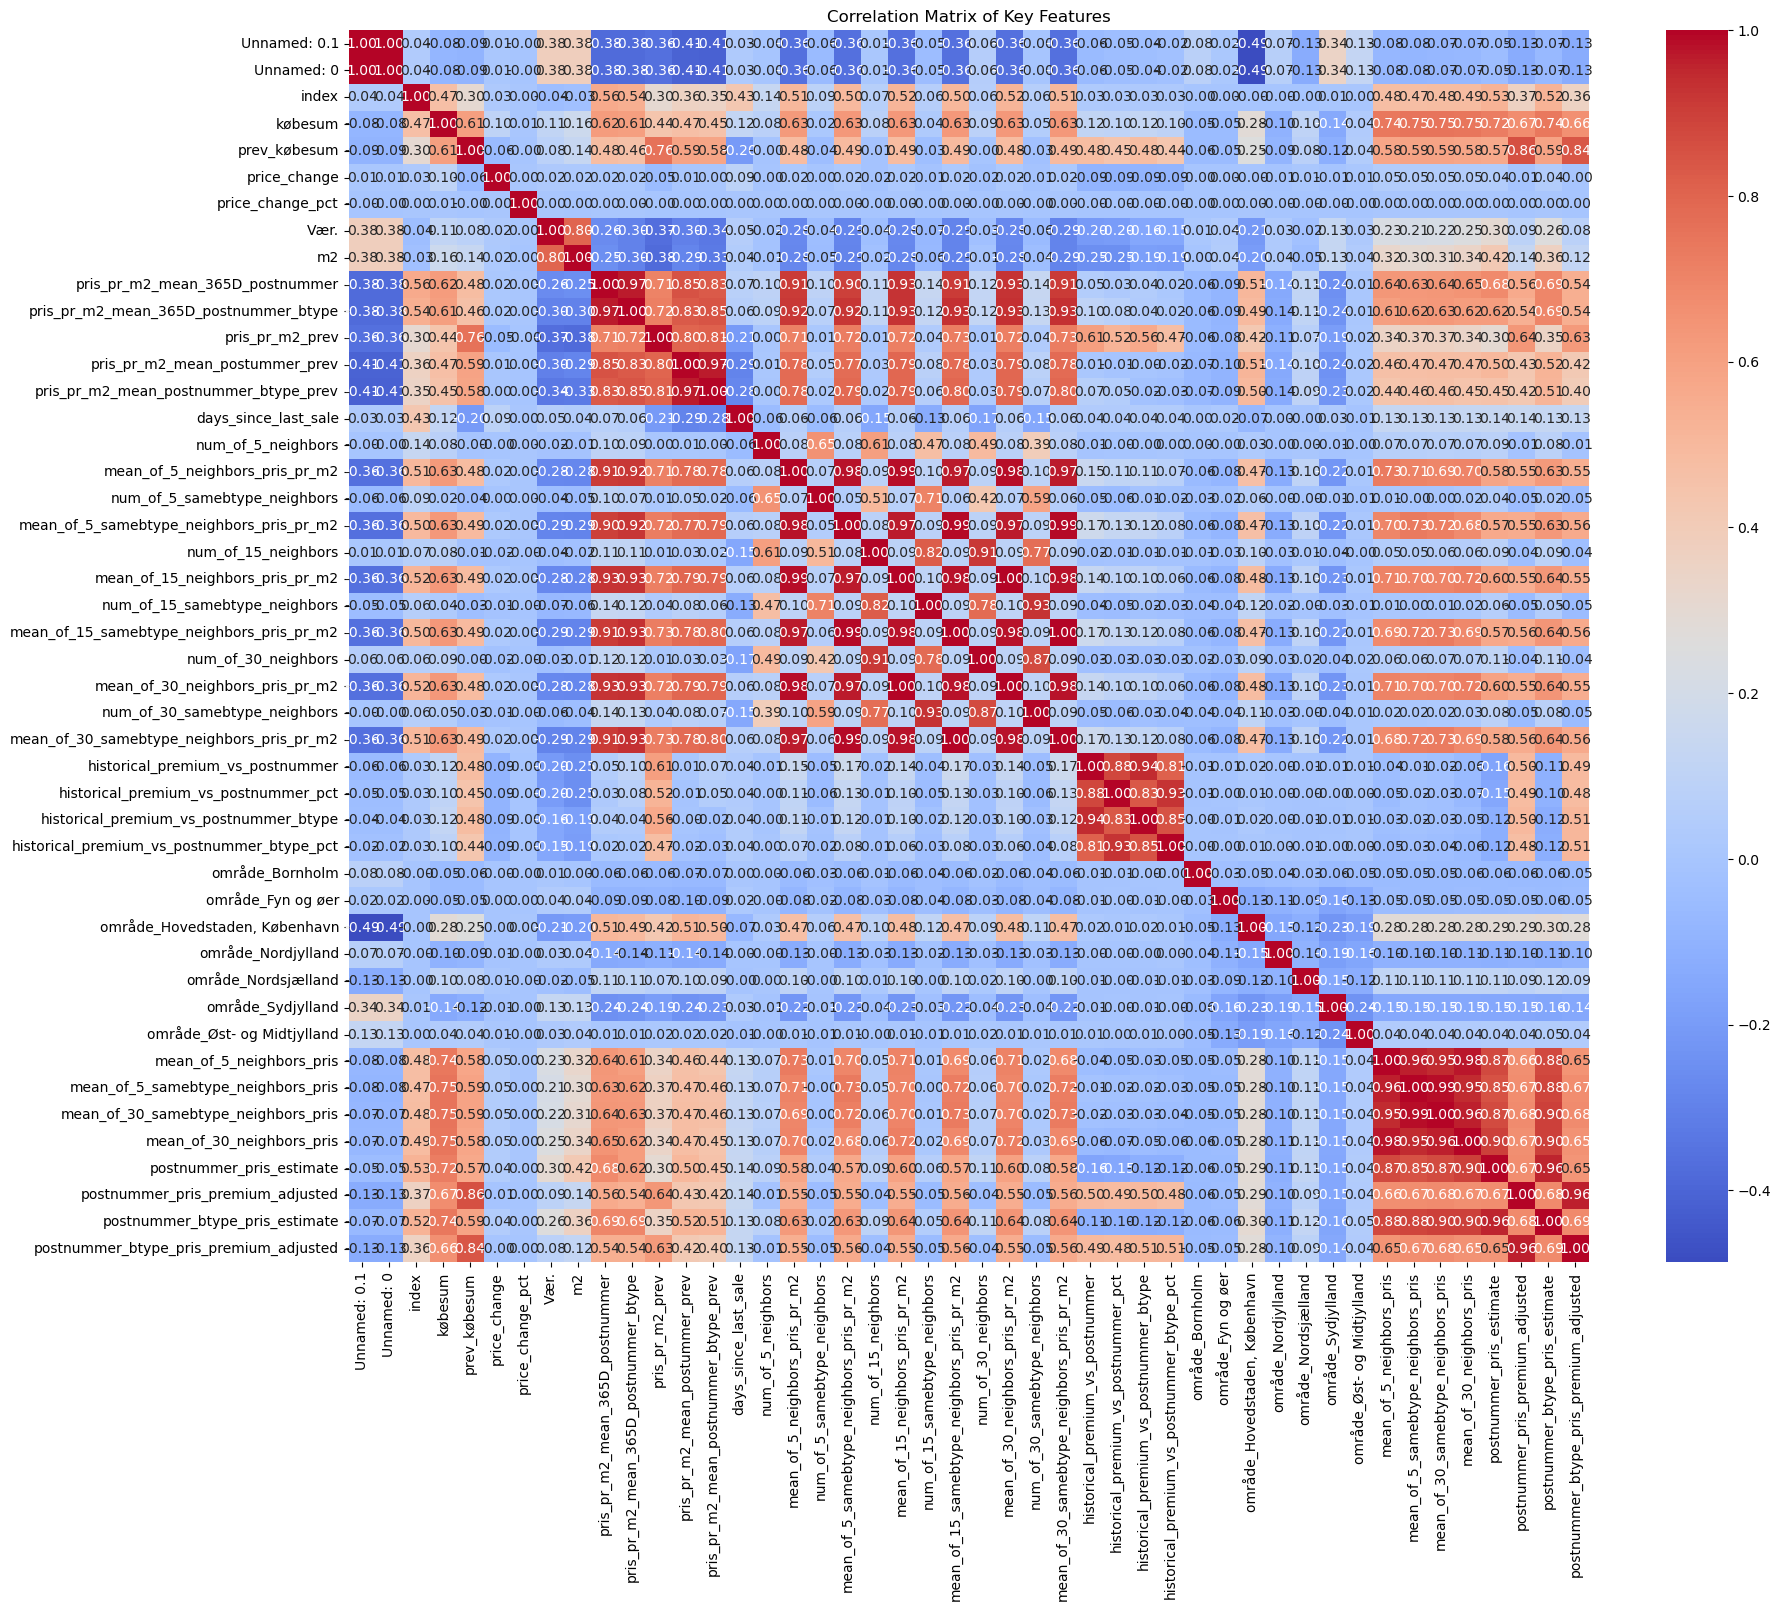

In [119]:
#putting away the bad
correlation_matrix = df.drop(columns=['dato','btype']).corr()
#correlation_matrix = df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features')
plt.show()

# honestly i could remove more features but i am going to wait to see what you say

overall mape: 47.6%

By building type:
        btype      mape   count
Ejerlejlighed 23.728941  408046
     Rækkehus 32.444987  172646
        Villa 52.251909 1323849
   Fritidshus 63.319021  280850
  Landejendom 88.820516   43589


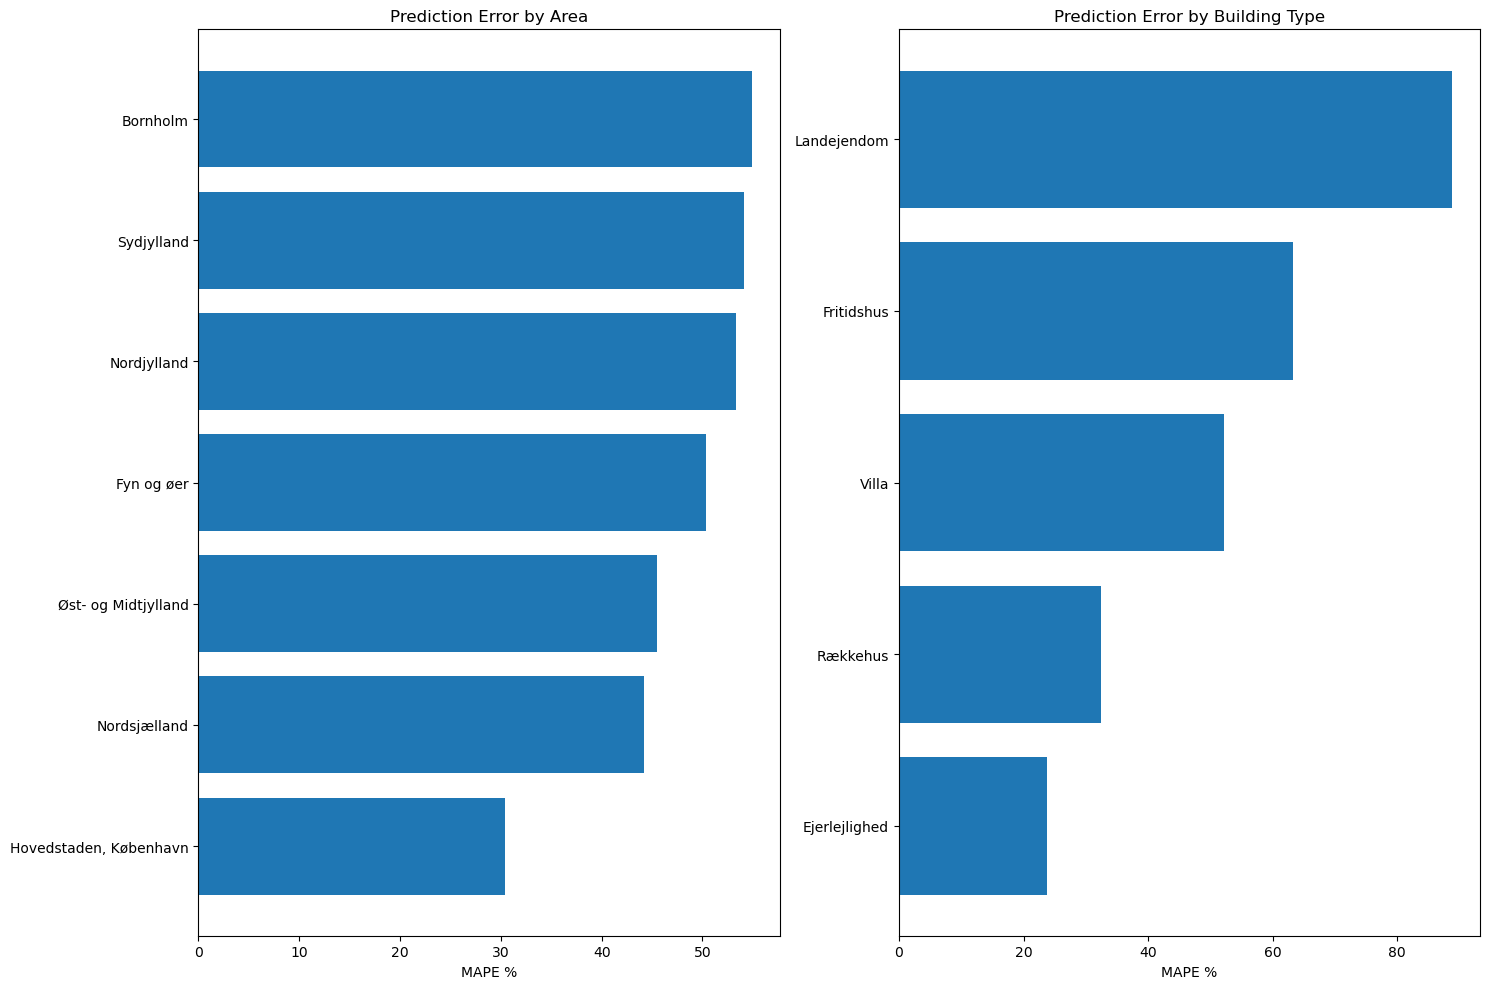


By area:
                  area      mape  count
Hovedstaden, København 30.448235 356520
          Nordsjælland 44.159032 162308
   Øst- og Midtjylland 45.513345 364972
            Fyn og øer 50.315531 187644
           Nordjylland 53.295040 252283
            Sydjylland 54.165536 489881
              Bornholm 54.900140  25815


In [120]:
# just checking how good the nn times price is by area 
df

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

actual = df['købesum']
pred = df['mean_of_30_samebtype_neighbors_pris']

# clean up the data
clean_data = df.dropna(subset=['købesum', 'mean_of_30_samebtype_neighbors_pris'])

print(f"overall mape: {mape(clean_data['købesum'], clean_data['mean_of_30_samebtype_neighbors_pris']):.1f}%")

# by area
area_cols = [col for col in clean_data.columns if 'område_' in col]

# quick plot by area
results = []
for col in area_cols:
    area_data = clean_data[clean_data[col] == 1]
    area_name = col.replace('område_', '')
    area_mape = mape(area_data['købesum'], area_data['mean_of_30_samebtype_neighbors_pris'])
    results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Prediction Error by Area')

if 'btype' in clean_data.columns:
    btype_results = []
    for btype in clean_data['btype'].unique():
            btype_data = clean_data[clean_data['btype'] == btype]
            btype_mape = mape(btype_data['købesum'], btype_data['mean_of_30_samebtype_neighbors_pris'])
            btype_results.append([btype, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [8]:
# Cell: Add BFE numbers and coordinates back to cleaned data
# Load the original data with BFE and coordinates
df_original = pd.read_csv("with_neighborstesttest.csv")  # This has bfe_nummer, x, y
df_filtered = df_original[
    (df_original['postnummer'] == 2960) & 
    (pd.to_datetime(df_original['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df_original['dato']) <= '2025-08-18')
]
print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

# Get the current cleaned data
df_cleaned = pd.read_csv("cleaned_data_harshertesttest.csv")

print(f"Original data shape: {df_original.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")

# Check if we have a common identifier to merge on
# Look for index or unique identifiers
if 'Unnamed: 0' in df_cleaned.columns and 'Unnamed: 0' in df_original.columns:
    # Merge on the index column
    df_with_bfe_coords = df_cleaned.merge(
        df_original[['Unnamed: 0', 'bfe_nummer', 'x', 'y', 'by', 'postnummer', 'pris_pr_m2']], 
        on='Unnamed: 0', 
        how='left'
    )
elif df_cleaned.index.name == df_original.index.name:
    # Merge on index if they match
    coords_data = df_original[['bfe_nummer', 'x', 'y', 'by', 'postnummer', 'pris_pr_m2']]
    df_with_bfe_coords = pd.concat([df_cleaned, coords_data], axis=1)
else:
    # Try to match by multiple columns (address + date + price)
    # This is more complex but doable if needed
    print("Need to identify matching method...")
    
    # Show what columns we have to work with
    print(f"Cleaned columns: {list(df_cleaned.columns)[:10]}...")
    print(f"Original columns: {list(df_original.columns)[:10]}...")

print(f"Final data with BFE and coords: {df_with_bfe_coords.shape}")
print(f"BFE numbers recovered: {df_with_bfe_coords['bfe_nummer'].notna().sum()}")
print(f"Coordinates recovered: {df_with_bfe_coords['x'].notna().sum()}")

# Filter for postnummer 2960 and date range
df_filtered = df_with_bfe_coords[
    (df_with_bfe_coords['postnummer'] == 2960) & 
    (pd.to_datetime(df_with_bfe_coords['dato']) >= '2024-01-01') & 
    (pd.to_datetime(df_with_bfe_coords['dato']) <= '2025-08-18')
]

print(f"Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: {len(df_filtered)}")

# Save the enhanced dataset
df_with_bfe_coords.to_csv("cleaned_data_with_bfe_coords.csv", index=False)
print("✅ Saved as 'cleaned_data_with_bfe_coords.csv'")

# Quick verification
df_with_bfe_coords[['købesum', 'bfe_nummer', 'x', 'y', 'm2', 'by', 'postnummer', 'pris_pr_m2']].head()

Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 8
Original data shape: (2352739, 57)
Cleaned data shape: (2352739, 49)
Final data with BFE and coords: (2352739, 55)
BFE numbers recovered: 2352739
Coordinates recovered: 2352739
Properties from postnummer 2960 sold between 2024-01-01 and 2025-08-18: 8


KeyboardInterrupt: 